# 05 - All sources side by side

The first four notebooks examined each source on its own. This one puts the seven sources (PTB-XL, MIMIC,
Georgia, CPSC 2018, CPSC-Extra, Chapman/Shaoxing and CODE-15) in one table to answer three questions:

1. How do the populations and the signals differ?
2. Do the same clinical findings show the same prevalence and the same relation to age and sex everywhere?
3. How identifiable is each source from its signal characteristics alone?

All numbers come from the cached per-record summaries built by `ecg_experiment/eda/` from the raw files (about 606,000
recordings with signals, and 1.2 million with metadata).

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ecg_experiment.eda.cross import CONDITIONS, combined_summary, condition_flags, source_fingerprint
from ecg_experiment.eda.stats import age_band, odds_ratios, plot_prevalence, prevalence

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

table = combined_summary()
ORDER = ["ptbxl", "mimic", "georgia", "cpsc_2018", "cpsc_2018_extra", "chapman_shaoxing", "code15"]
LABELED = ["ptbxl", "georgia", "cpsc_2018", "cpsc_2018_extra", "chapman_shaoxing", "code15"]

## 1. Populations and signals

In [3]:
overview = table.groupby("source").agg(
    records=("std", "size"),
    median_duration_s=("duration_s", "median"),
    median_age=("age", "median"),
    male_share=("male", "mean"),
    signal_std=("std", "median"),
    low_frequency_power=("baseline_fraction", "median"),
    high_frequency_power=("high_frequency_fraction", "median"),
    heart_rate=("heart_rate", "median"),
).loc[ORDER]
overview.loc["mimic", ["median_age", "male_share"]] = np.nan
display(overview.round(3))
problems = table.assign(
    nan=table["nan_leads"] > 0, constant_lead=table["constant_leads"] > 0,
    over_10_units=table["large_leads"] > 0, flat_1s=table["flat_leads"] > 0,
).groupby("source")[["nan", "constant_lead", "flat_1s", "over_10_units"]].mean().loc[ORDER]
display((problems * 100).round(2).rename(columns=lambda name: f"% {name}"))

,records,median_duration_s,median_age,male_share,signal_std,low_frequency_power,high_frequency_power,heart_rate
source,,,,,,,,
ptbxl,21799,10.000,61.0,0.521,0.152,0.020,0.007,71.259
mimic,200000,10.000,NaN,NaN,0.133,0.008,0.011,74.627
georgia,10344,10.000,62.0,0.537,0.143,0.024,0.008,75.282
cpsc_2018,6877,12.000,64.0,0.538,0.149,0.007,0.006,76.923
cpsc_2018_extra,3453,12.000,65.0,0.534,0.144,0.006,0.005,76.628
chapman_shaoxing,10247,10.000,62.0,0.559,0.151,0.023,0.012,73.529
code15,343809,7.335,54.0,0.403,0.316,0.023,0.001,71.006


,% nan,% constant_lead,% flat_1s,% over_10_units
source,,,,
ptbxl,0.00,0.00,0.01,0.22
mimic,1.31,0.24,0.50,0.25
georgia,0.06,0.09,0.12,0.17
cpsc_2018,0.00,0.26,0.86,1.44
cpsc_2018_extra,0.00,0.23,0.87,1.59
chapman_shaoxing,0.00,0.15,0.17,0.21
code15,0.00,0.31,1.60,11.65


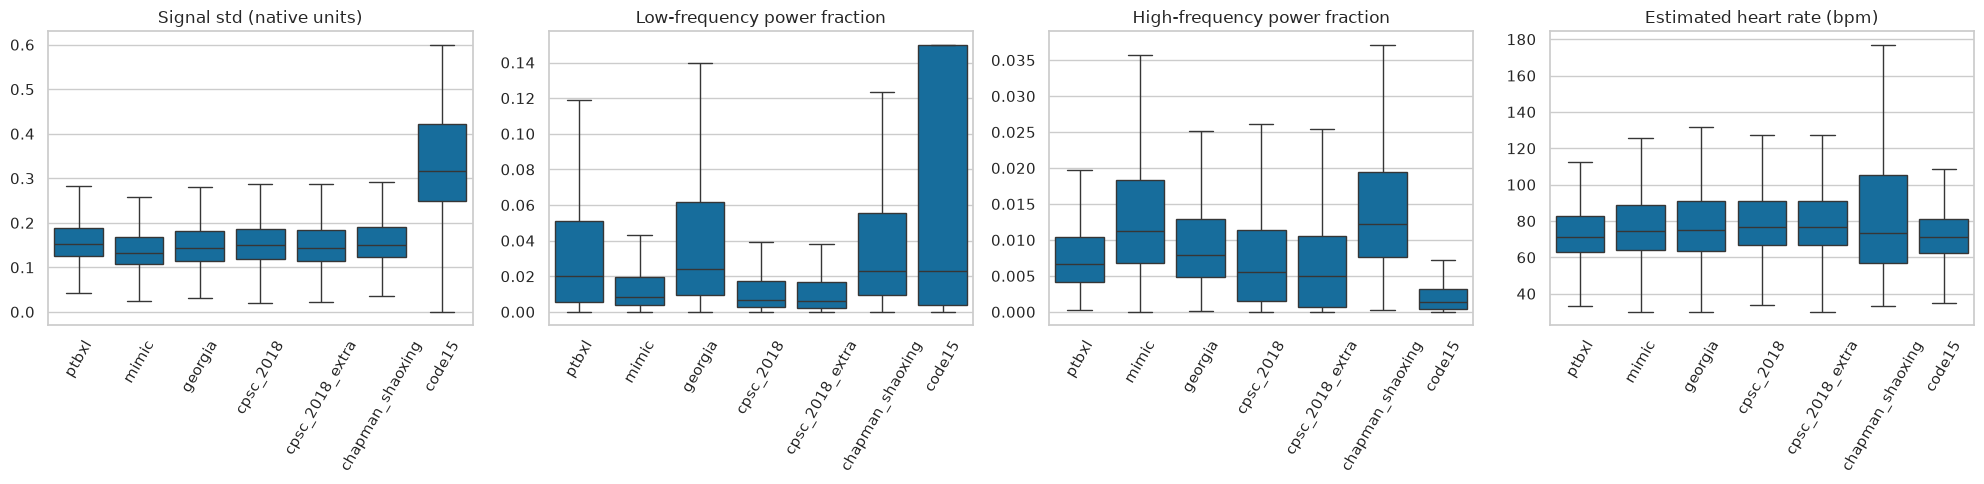

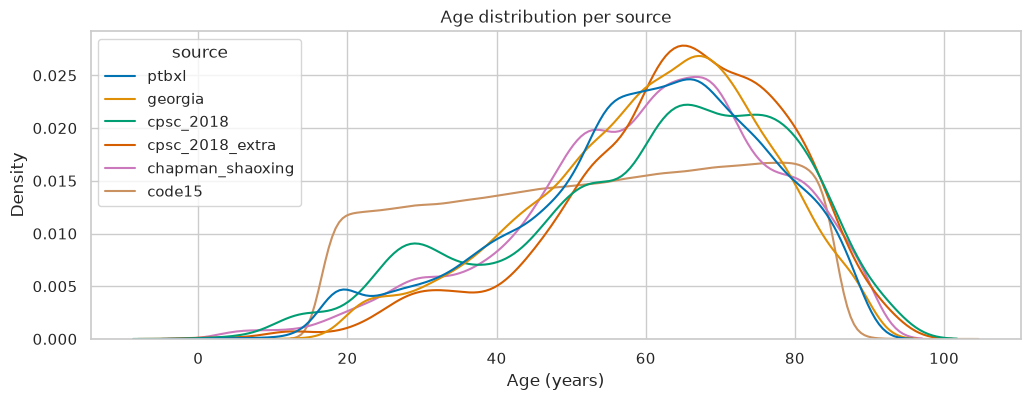

In [4]:
plotted = table.assign(
    std=table["std"].clip(upper=0.6), baseline_fraction=table["baseline_fraction"].clip(upper=0.15),
    high_frequency_fraction=table["high_frequency_fraction"].clip(upper=0.05),
    heart_rate=table["heart_rate"].clip(30, 200))
metrics = {"std": "Signal std (native units)", "baseline_fraction": "Low-frequency power fraction",
           "high_frequency_fraction": "High-frequency power fraction",
           "heart_rate": "Estimated heart rate (bpm)"}
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for axis, (column, title) in zip(axes, metrics.items(), strict=True):
    sns.boxplot(plotted, x="source", y=column, order=ORDER, showfliers=False, ax=axis)
    axis.set(title=title, xlabel="", ylabel="")
    axis.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()
known = table[table["source"] != "mimic"].dropna(subset=["age"])
fig, ax = plt.subplots(figsize=(12, 4))
sns.kdeplot(known, x="age", hue="source", hue_order=[source for source in ORDER if source != "mimic"],
            common_norm=False, ax=ax)
ax.set(title="Age distribution per source", xlabel="Age (years)")
plt.show()

**Finding.** Six sources agree closely in amplitude (median signal standard deviation 0.13-0.15 mV), which
confirms their mV units against one another. **CODE-15 is the outlier at about 0.32**, the scale issue from
notebook 04. The hospital and cardiology cohorts (PTB-XL, Georgia, CPSC, Chapman) have median ages of 61-65;
CODE-15's primary-care population is younger (54) and mostly female. The noise profiles split the sources into
groups: CPSC 2018 and CPSC-Extra are heavily filtered, and Chapman and MIMIC carry the most high-frequency
content. Integrity problems are rare everywhere: at most about 1.5% of records per category (MIMIC's NaN gaps,
CPSC's rail artifacts), except large-amplitude values in CODE-15 (12%), which are inflated by its scale.

## 2. The same findings across sources

Six findings exist in (almost) every source: atrial fibrillation, right and left bundle branch block,
first-degree AV block, sinus bradycardia and sinus tachycardia. They were annotated very differently:
cardiologists in PTB-XL, challenge organizers' readers for the Challenge sets, an automatic system reviewed by
cardiologists in CODE-15, and the cart's automatic report in MIMIC. So prevalences are comparable only
approximately.

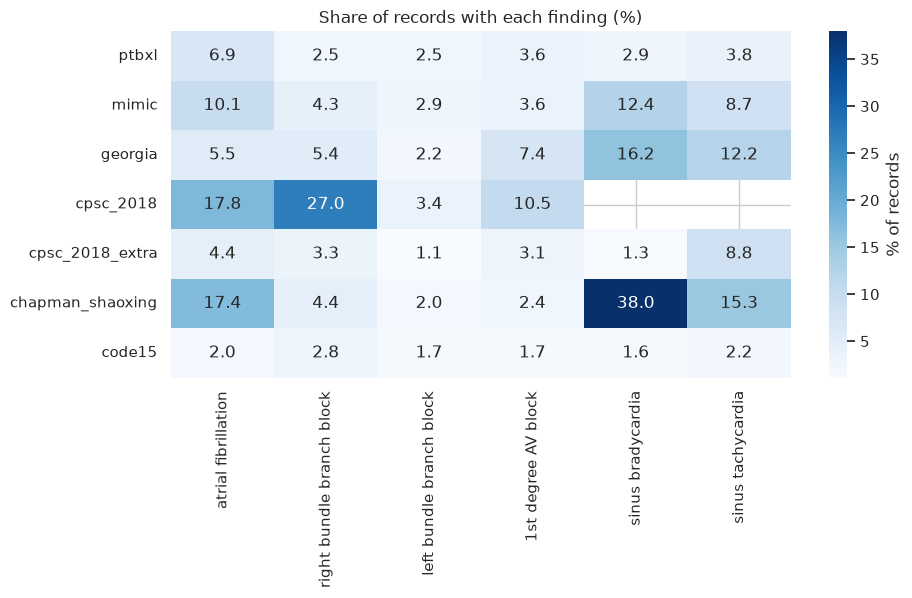

In [5]:
flags = condition_flags()
flags["age_band"] = age_band(flags["age"])
shares = flags.groupby("source")[CONDITIONS].mean().loc[ORDER]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(shares * 100, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of records"}, ax=ax)
ax.set(title="Share of records with each finding (%)", xlabel="", ylabel="")
plt.show()

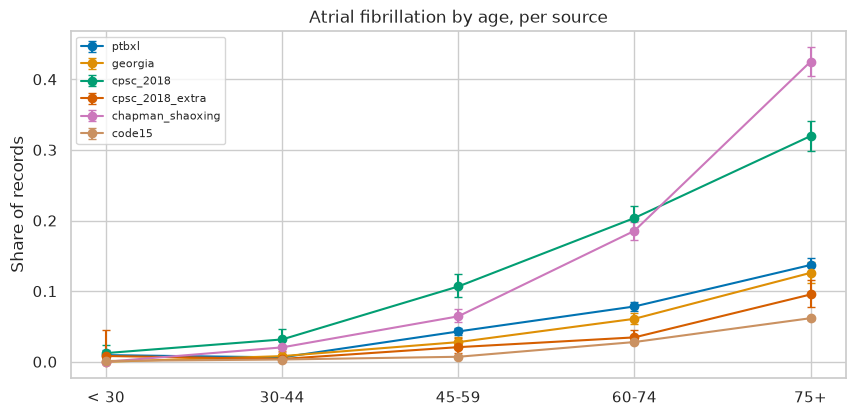

In [6]:
atrial = pd.concat([prevalence(flags[flags["source"] == source].dropna(subset=["age_band"]), "age_band",
                               ["atrial fibrillation"]).assign(outcome=source) for source in LABELED])
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_prevalence(atrial, "age_band", ax, "Atrial fibrillation by age, per source")
plt.show()

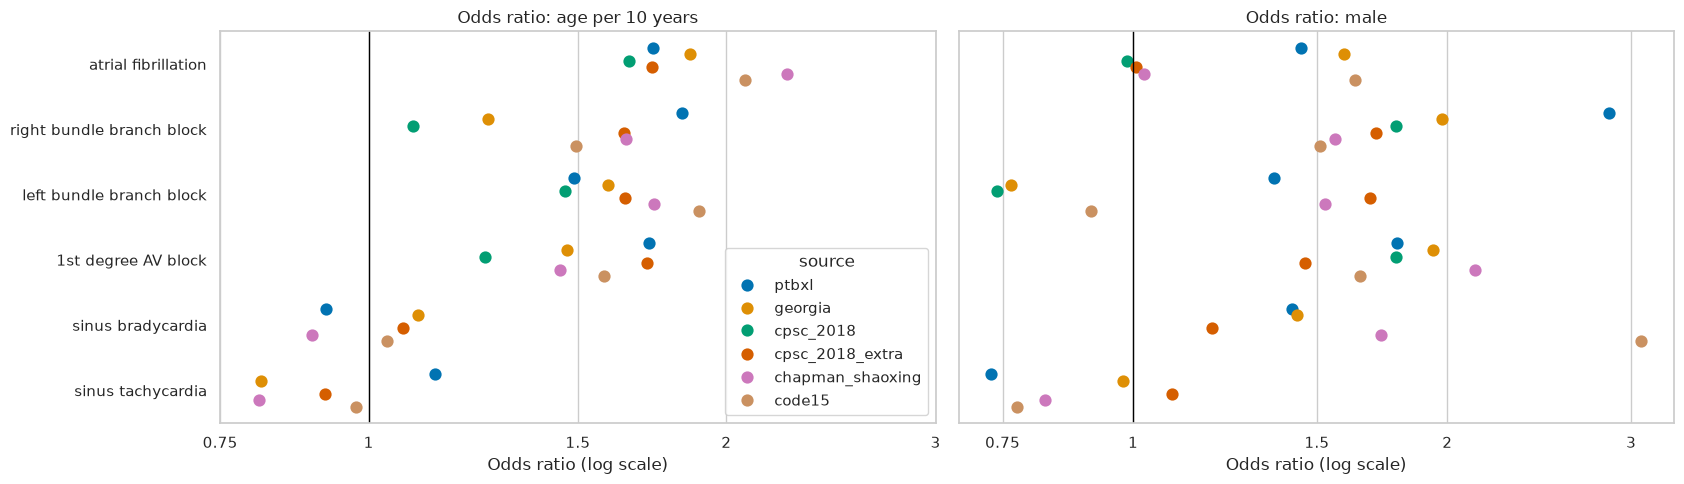

predictor                 age per 10 years                                                            male                                               
source                    chapman_shaoxing code15 cpsc_2018 cpsc_2018_extra georgia ptbxl chapman_shaoxing code15 cpsc_2018 cpsc_2018_extra georgia ptbxl
outcome                                                                                                                                                  
atrial fibrillation                   2.25   2.07      1.66            1.73    1.86  1.74             1.02   1.63      0.99            1.01    1.59  1.45
right bundle branch block             1.65   1.49      1.09            1.64    1.26  1.83             1.56   1.51      1.79            1.71    1.98  2.86
left bundle branch block              1.74   1.90      1.46            1.64    1.59  1.49             1.53   0.91      0.74            1.69    0.76  1.36
1st degree AV block                   1.45   1.58      1.25            1.71    1.47  1.72             2.12   1.65      1.78            1.46    1.94  1.79
sinus bradycardia                     0.90   1.04       NaN            1.07    1.10  0.92             1.73   3.07       NaN            1.19    1.43  1.42
sinus tachycardia                     0.81   0.97       NaN            0.92    0.81  1.14             0.82   0.77       NaN            1.09    0.98  0.73

In [7]:
rows = []
for source in LABELED:
    subset = flags[flags["source"] == source]
    usable = [condition for condition in CONDITIONS if subset[condition].sum() >= 30]
    rows.append(odds_ratios(subset, usable).assign(source=source))
ratios = pd.concat(rows)
fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)
for axis, predictor in zip(axes, ["age per 10 years", "male"], strict=True):
    subset = ratios[ratios["predictor"] == predictor]
    sns.pointplot(subset, x="odds_ratio", y="outcome", hue="source", order=CONDITIONS, hue_order=LABELED,
                  dodge=0.5, linestyle="none", errorbar=None, ax=axis)
    axis.axvline(1, color="black", linewidth=1)
    axis.set(xscale="log", title=f"Odds ratio: {predictor}", xlabel="Odds ratio (log scale)", ylabel="")
    ticks = [0.75, 1, 1.5, 2, 3]
    axis.set_xticks(ticks, [str(tick) for tick in ticks])
    axis.minorticks_off()
axes[1].legend_.remove()
plt.tight_layout()
plt.show()
display(ratios.pivot_table(index="outcome", columns=["predictor", "source"], values="odds_ratio")
        .reindex(CONDITIONS).round(2))

**Finding: prevalences differ a lot, but the age and sex patterns replicate.**

- **Prevalence depends on how each source was assembled.** Atrial fibrillation ranges from about 2% of exams in
  CODE-15 (primary care) to about 17-18% in CPSC 2018 and Chapman (collections enriched for arrhythmia), with
  PTB-XL and MIMIC in between. Sinus bradycardia is especially common in Chapman.
- **Atrial fibrillation rises with age in every source**, with odds ratios of about 1.7-2.3 per decade, which
  makes it one of the most age-dependent findings (in PTB-XL, right bundle branch block rises slightly faster).
- **Right bundle branch block is more common in men in every source** (odds ratio 1.5-2.9), and first-degree
  AV block is too.
- **Left bundle branch block has no consistent sex pattern.** It is less common in men in Georgia, CPSC 2018
  and CODE-15, and more common in men in PTB-XL, CPSC-Extra and Chapman.
- **Sinus tachycardia becomes less common with age** in four of the five sources that label it (PTB-XL is the
  exception), while sinus bradycardia barely depends on age and is more common in men everywhere.

Because the directions agree across six populations on three continents and four annotation methods, these
are properties of cardiology rather than quirks of one dataset.

## 3. Can the source be recognized without looking at the heart?

If the source can be predicted from amplitude and noise statistics alone, those statistics carry a strong
"dataset signature". We train a small classifier on six non-cardiac features (signal spread, low- and
high-frequency power, 50 and 60 Hz power, and exact-zero fraction), with an equal number of records per source.

Balanced accuracy: 0.65 (chance: 0.14)


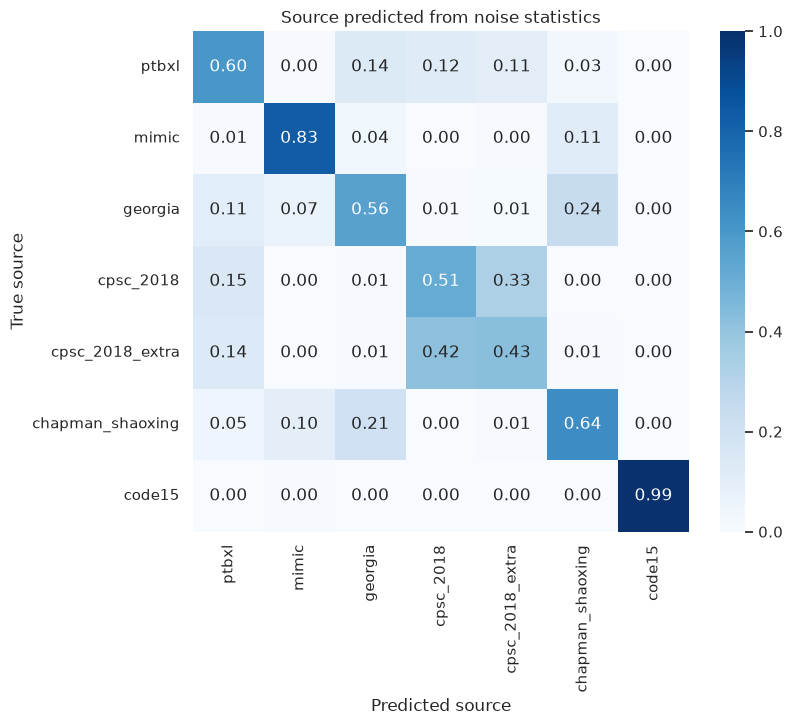

In [8]:
accuracy, confusion = source_fingerprint(table, per_source=3000)
print(f"Balanced accuracy: {accuracy:.2f} (chance: {1 / len(ORDER):.2f})")
confusion = confusion.loc[ORDER, ORDER]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(confusion, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set(xlabel="Predicted source", ylabel="True source", title="Source predicted from noise statistics")
plt.show()

**Finding: every source leaves a fingerprint.** With no cardiac information, the classifier names the source
correctly about 65% of the time, against 14% by chance. CODE-15 is recognized almost perfectly (99%, its scale)
and MIMIC about 80% of the time (its filtering). The confusions are informative: CPSC 2018 and CPSC-Extra are
mistaken for each other (same hospitals and pipeline), and Georgia and Chapman overlap. Differences between
sources in any downstream analysis therefore mix clinical differences with acquisition differences.

## 4. Conclusions across the datasets

- **Units and scale.** Six sources are genuinely in mV and agree with one another; CODE-15 is about 2x larger.
- **Populations.** Hospital and cardiology cohorts in their early sixties, and one younger, mostly female
  primary-care cohort (CODE-15). MIMIC has no demographics in its waveform release.
- **Findings.** Prevalences vary several-fold with how each collection was assembled. But the associations with
  age and sex replicate across all sources: atrial fibrillation rises steeply with age, right bundle branch
  block is male-dominated, and left bundle branch block has no consistent sex pattern.
- **Acquisition.** Filtering and noise differ enough that the source is identifiable from signal statistics
  alone, so comparisons across sources should account for acquisition.
- **Quality.** Integrity problems are rare (about 1.5% or less per category) in every source. The specific
  quirks are documented in each notebook: PTB-XL's age placeholder, MIMIC's lead order and missing-value
  codes, CPSC's rail artifacts and duplicates, and CODE-15's padding and filler rows.